In [ ]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.utils import load_img, img_to_array, to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout,
    Input
)

from tensorflow.keras.models import Model,load_model
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix
os.chdir(r"D:\proj-python\Face Mask Dataset")

# ============================================================
# 2. CHECK GPU
# ============================================================

print("=" * 60)
print("GPU CHECK")
print("=" * 60)

print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("GPU available:")
    for gpu in gpus:
        print(gpu)
else:
    print("WARNING: GPU NOT AVAILABLE")




# ============================================================
# 4. CONFIGURATION
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 32

NUM_CLASSES = 2

LR_STAGE1 = 1e-3
LR_STAGE2 = 1e-5

EPOCHS_STAGE1 = 5
EPOCHS_STAGE2 = 7

categories = [
    "WithMask",
    "WithoutMask"
]


# ============================================================
# 5. DATASET PATHS
# ============================================================

train_path = (
    "Train"
)

valid_path = (
    "Validation"
)

test_path = (
    "Test"
)


# ============================================================
# 6. CHECK DATASET PATHS
# ============================================================

print("\n" + "=" * 60)
print("CHECKING DATASET")
print("=" * 60)

print("Train path exists:", os.path.exists(train_path))
print("Validation path exists:", os.path.exists(valid_path))
print("Test path exists:", os.path.exists(test_path))

for path in [train_path, valid_path, test_path]:

    print("\nPath:", path)

    if os.path.exists(path):

        for category in categories:

            category_path = os.path.join(
                path,
                category
            )

            if os.path.exists(category_path):

                files = os.listdir(category_path)

                print(
                    category,
                    "->",
                    len(files),
                    "images"
                )

            else:

                print(
                    "WARNING:",
                    category_path,
                    "does not exist"
                )


# ============================================================
# 7. FUNCTION TO LOAD DATASET
# ============================================================

def load_dataset(dataset_path):

    data = []
    labels = []

    print("\nLoading:", dataset_path)

    for category in categories:

        category_path = os.path.join(
            dataset_path,
            category
        )

        print(
            "Loading category:",
            category
        )

        for image_name in os.listdir(category_path):

            image_path = os.path.join(
                category_path,
                image_name
            )

            try:

                image = load_img(
                    image_path,
                    target_size=(IMG_SIZE, IMG_SIZE)
                )

                image = img_to_array(image)

                image = preprocess_input(image)

                data.append(image)

                labels.append(category)

            except Exception as e:

                print(
                    "Error loading:",
                    image_path
                )

                print(e)

    data = np.array(
        data,
        dtype="float32"
    )

    labels = np.array(labels)

    return data, labels


# ============================================================
# 8. LOAD TRAIN DATA
# ============================================================

print("\n" + "=" * 60)
print("LOADING TRAIN DATA")
print("=" * 60)

train_x, train_y = load_dataset(train_path)

print("\nTrain X shape:")
print(train_x.shape)

print("\nTrain Y shape:")
print(train_y.shape)

print("\nSample labels:")
print(train_y[:10])


# ============================================================
# 9. LOAD VALIDATION DATA
# ============================================================

print("\n" + "=" * 60)
print("LOADING VALIDATION DATA")
print("=" * 60)

valid_x, valid_y = load_dataset(valid_path)

print("\nValidation X shape:")
print(valid_x.shape)

print("\nValidation Y shape:")
print(valid_y.shape)


# ============================================================
# 10. LOAD TEST DATA
# ============================================================

print("\n" + "=" * 60)
print("LOADING TEST DATA")
print("=" * 60)

test_x, test_y = load_dataset(test_path)

print("\nTest X shape:")
print(test_x.shape)

print("\nTest Y shape:")
print(test_y.shape)

print("\nSample labels:")
print(test_y[:10])


# ============================================================
# 11. ENCODE LABELS
# ============================================================

print("\n" + "=" * 60)
print("ENCODING LABELS")
print("=" * 60)

lb = LabelBinarizer()

train_y = lb.fit_transform(train_y)

valid_y = lb.transform(valid_y)

test_y = lb.transform(test_y)


# Convert to categorical

train_y = to_categorical(
    train_y,
    num_classes=NUM_CLASSES
)

valid_y = to_categorical(
    valid_y,
    num_classes=NUM_CLASSES
)

test_y = to_categorical(
    test_y,
    num_classes=NUM_CLASSES
)


print("\nFinal shapes:")

print(
    "Train:",
    train_x.shape,
    train_y.shape
)

print(
    "Validation:",
    valid_x.shape,
    valid_y.shape
)

print(
    "Test:",
    test_x.shape,
    test_y.shape
)


# ============================================================
# 12. DATA AUGMENTATION
# ============================================================

print("\n" + "=" * 60)
print("CREATING DATA AUGMENTATION")
print("=" * 60)

augmentation = ImageDataGenerator(

    rotation_range=15,

    zoom_range=0.10,

    width_shift_range=0.10,

    height_shift_range=0.10,

    shear_range=0.10,

    horizontal_flip=True,

    fill_mode="nearest"
)


# ============================================================
# 13. CREATE MOBILENETV2 BASE MODEL
# ============================================================

print("\n" + "=" * 60)
print("CREATING MOBILENETV2")
print("=" * 60)

base_model = MobileNetV2(

    weights="imagenet",

    include_top=False,

    input_shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)


# Freeze MobileNetV2

base_model.trainable = False


# ============================================================
# 14. CREATE CLASSIFICATION HEAD
# ============================================================

print("\n" + "=" * 60)
print("CREATING MODEL")
print("=" * 60)

inputs = Input(
    shape=(
        IMG_SIZE,
        IMG_SIZE,
        3
    )
)


# MobileNetV2

x = base_model(
    inputs,
    training=False
)


# Convert feature maps to vector

x = GlobalAveragePooling2D()(x)


# Fully connected layer

x = Dense(
    128,
    activation="relu"
)(x)


# Dropout

x = Dropout(
    0.4
)(x)


# Output

outputs = Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)


# Complete model

model = Model(
    inputs=inputs,
    outputs=outputs
)


# ============================================================
# 15. MODEL SUMMARY
# ============================================================

model.summary()


# ============================================================
# 16. COMPILE STAGE 1
# ============================================================

print("\n" + "=" * 60)
print("COMPILE STAGE 1")
print("=" * 60)

optimizer = Adam(
    learning_rate=LR_STAGE1
)

model.compile(

    optimizer=optimizer,

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)


# ============================================================
# 17. CALLBACKS
# ============================================================

checkpoint_stage1 = tf.keras.callbacks.ModelCheckpoint(

    "best_mask_detector_stage1.weights.h5",

    monitor="val_accuracy",

    mode="max",

    save_best_only=True,

    save_weights_only=True,

    verbose=1
)


early_stop_stage1 = tf.keras.callbacks.EarlyStopping(

    monitor="val_accuracy",

    mode="max",

    patience=5,

    restore_best_weights=True,

    verbose=1
)


reduce_lr_stage1 = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.3,

    patience=2,

    min_lr=1e-7,

    verbose=1
)


# ============================================================
# 18. STAGE 1 TRAINING
# ============================================================

print("\n" + "=" * 60)
print("STAGE 1 TRAINING")
print("=" * 60)

history1 = model.fit(

    augmentation.flow(
        train_x,
        train_y,
        batch_size=BATCH_SIZE,
        shuffle=True
    ),

    steps_per_epoch=max(
        1,
        len(train_x) // BATCH_SIZE
    ),

    validation_data=(
        valid_x,
        valid_y
    ),

    epochs=EPOCHS_STAGE1,

    callbacks=[
        checkpoint_stage1,
        early_stop_stage1,
        reduce_lr_stage1
    ]
)




Loading best Stage 1 weights...

STARTING FINE-TUNING
Total MobileNetV2 layers: 154
Trainable MobileNetV2 layers:
block_13_project_BN
block_14_expand
block_14_expand_BN
block_14_expand_relu
block_14_depthwise
block_14_depthwise_BN
block_14_depthwise_relu
block_14_project
block_14_project_BN
block_14_add
block_15_expand
block_15_expand_BN
block_15_expand_relu
block_15_depthwise
block_15_depthwise_BN
block_15_depthwise_relu
block_15_project
block_15_project_BN
block_15_add
block_16_expand
block_16_expand_BN
block_16_expand_relu
block_16_depthwise
block_16_depthwise_BN
block_16_depthwise_relu
block_16_project
block_16_project_BN
Conv_1
Conv_1_bn
out_relu

STAGE 2 FINE-TUNING
Epoch 1/2
312/312 [==============================] - ETA: 0s - loss: 0.0155 - accuracy: 0.9948
Epoch 1: val_accuracy improved from -inf to 0.99750, saving model to best_mask_detector_finetuned.weights.h5
312/312 [==============================] - 335s 1s/step - loss: 0.0155 - accuracy: 0.9948 - val_loss: 0.0131 - val

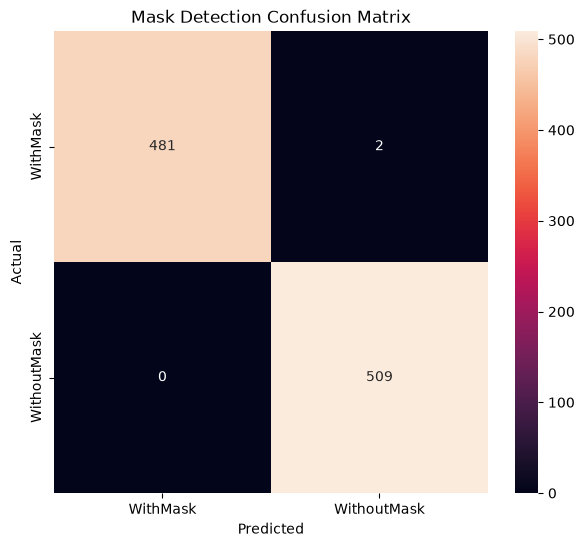

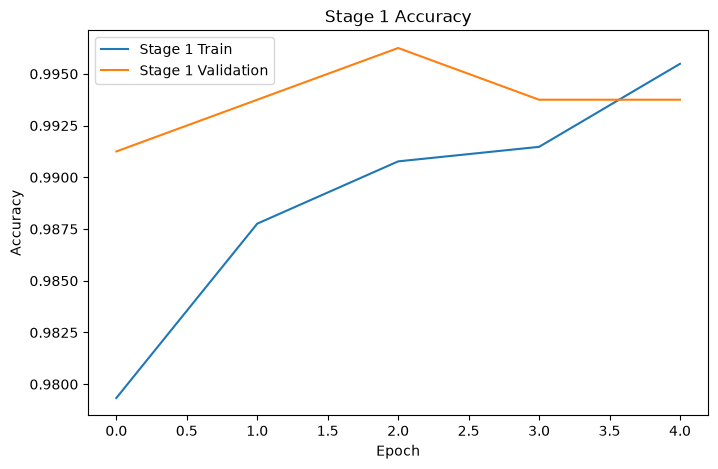

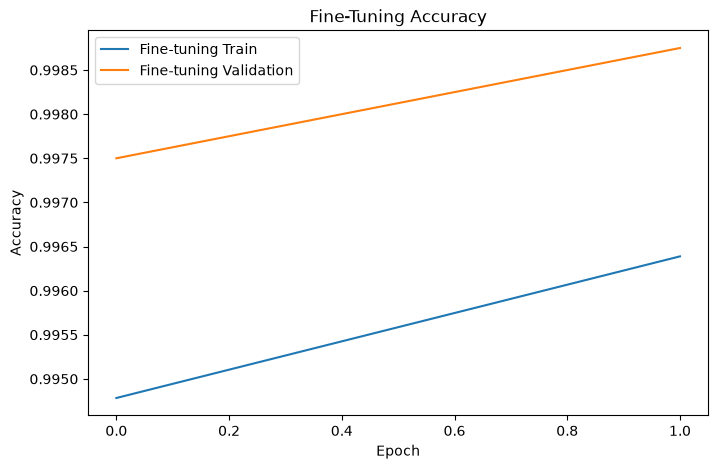

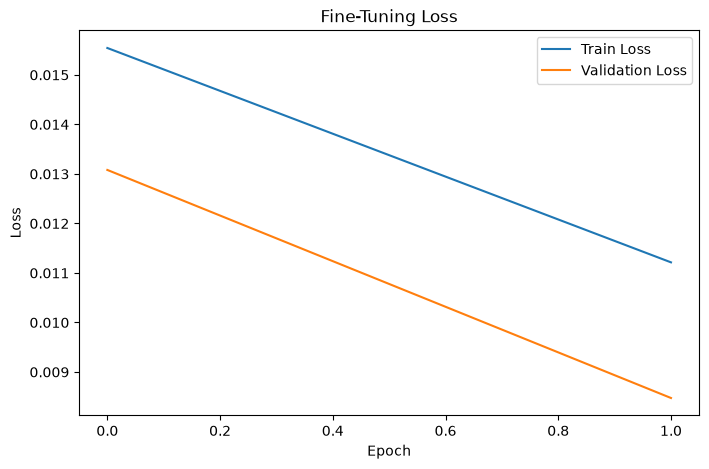


SAVING MODEL
Saved: mask_detector.keras
Saved: mask_detector.weights.h5

FINAL RESULTS
Test Accuracy: 0.9980
Test Accuracy: 99.80%


In [5]:
IMG_SIZE = 224
BATCH_SIZE = 32

NUM_CLASSES = 2

LR_STAGE2 = 1e-5

EPOCHS_STAGE2 = 2

# ============================================================
# 19. LOAD BEST STAGE 1 WEIGHTS
# ============================================================

print("\nLoading best Stage 1 weights...")

model.load_weights(
    "best_mask_detector_stage1.weights.h5"
)


# ============================================================
# 20. FINE-TUNING
# ============================================================

print("\n" + "=" * 60)
print("STARTING FINE-TUNING")
print("=" * 60)


# Unfreeze base model

base_model.trainable = True


# Freeze early layers
# Train only last 30 layers

for layer in base_model.layers[:-30]:

    layer.trainable = False


print(
    "Total MobileNetV2 layers:",
    len(base_model.layers)
)


print(
    "Trainable MobileNetV2 layers:"
)

for layer in base_model.layers:

    if layer.trainable:

        print(
            layer.name
        )


# ============================================================
# 21. RECOMPILE WITH SMALL LEARNING RATE
# ============================================================

model.compile(

    optimizer=Adam(
        learning_rate=LR_STAGE2
    ),

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)


# ============================================================
# 22. FINE-TUNING CALLBACKS
# ============================================================

checkpoint_stage2 = tf.keras.callbacks.ModelCheckpoint(

    "best_mask_detector_finetuned.weights.h5",

    monitor="val_accuracy",

    mode="max",

    save_best_only=True,

    save_weights_only=True,

    verbose=1
)


early_stop_stage2 = tf.keras.callbacks.EarlyStopping(

    monitor="val_accuracy",

    mode="max",

    patience=7,

    restore_best_weights=True,

    verbose=1
)


reduce_lr_stage2 = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.3,

    patience=2,

    min_lr=1e-7,

    verbose=1
)


# ============================================================
# 23. STAGE 2 TRAINING
# ============================================================

print("\n" + "=" * 60)
print("STAGE 2 FINE-TUNING")
print("=" * 60)

history2 = model.fit(

    augmentation.flow(
        train_x,
        train_y,
        batch_size=BATCH_SIZE,
        shuffle=True
    ),

    steps_per_epoch=max(
        1,
        len(train_x) // BATCH_SIZE
    ),

    validation_data=(
        valid_x,
        valid_y
    ),

    epochs=EPOCHS_STAGE2,

    callbacks=[
        checkpoint_stage2,
        early_stop_stage2,
        reduce_lr_stage2
    ]
)


# ============================================================
# 24. LOAD BEST FINE-TUNED WEIGHTS
# ============================================================

print("\n" + "=" * 60)
print("LOADING BEST WEIGHTS")
print("=" * 60)

model.load_weights(
    "best_mask_detector_finetuned.weights.h5"
)


# ============================================================
# 25. TEST MODEL
# ============================================================

print("\n" + "=" * 60)
print("TESTING MODEL")
print("=" * 60)

loss, accuracy = model.evaluate(

    test_x,

    test_y,

    batch_size=BATCH_SIZE,

    verbose=1
)


print("\nTest Loss:")
print(loss)

print("\nTest Accuracy:")
print(accuracy)


# ============================================================
# 26. PREDICTIONS
# ============================================================

print("\n" + "=" * 60)
print("GENERATING PREDICTIONS")
print("=" * 60)

predictions = model.predict(

    test_x,

    batch_size=BATCH_SIZE,

    verbose=1
)


predicted_classes = np.argmax(
    predictions,
    axis=1
)

actual_classes = np.argmax(
    test_y,
    axis=1
)


# ============================================================
# 27. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(

        actual_classes,

        predicted_classes,

        target_names=categories
    )
)


# ============================================================
# 28. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    actual_classes,

    predicted_classes
)


plt.figure(
    figsize=(7, 6)
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=categories,

    yticklabels=categories
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.title(
    "Mask Detection Confusion Matrix"
)

plt.show()


# ============================================================
# 29. PLOT TRAINING ACCURACY
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history1.history["accuracy"],
    label="Stage 1 Train"
)

plt.plot(
    history1.history["val_accuracy"],
    label="Stage 1 Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Stage 1 Accuracy"
)

plt.legend()

plt.show()


# ============================================================
# 30. PLOT FINE-TUNING ACCURACY
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history2.history["accuracy"],
    label="Fine-tuning Train"
)

plt.plot(
    history2.history["val_accuracy"],
    label="Fine-tuning Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Fine-Tuning Accuracy"
)

plt.legend()

plt.show()


# ============================================================
# 31. PLOT FINE-TUNING LOSS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history2.history["loss"],
    label="Train Loss"
)

plt.plot(
    history2.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Fine-Tuning Loss"
)

plt.legend()

plt.show()


# ============================================================
# 32. SAVE COMPLETE MODEL
# ============================================================

print("\n" + "=" * 60)
print("SAVING MODEL")
print("=" * 60)

model.save(
    "mask_detector.keras"
)

print(
    "Saved: mask_detector.keras"
)


# ============================================================
# 33. SAVE FINAL WEIGHTS
# ============================================================

model.save_weights(

    "mask_detector.weights.h5"
)

print(
    "Saved: mask_detector.weights.h5"
)


# ============================================================
# 34. SHOW TRAINING RESULTS
# ============================================================

print("\n" + "=" * 60)
print("FINAL RESULTS")
print("=" * 60)

print(
    f"Test Accuracy: {accuracy:.4f}"
)

print(
    f"Test Accuracy: {accuracy * 100:.2f}%"
)


# ============================================================
# 35. SINGLE IMAGE PREDICTION FUNCTION
# ============================================================

def predict_image(image_path):

    image = load_img(

        image_path,

        target_size=(
            IMG_SIZE,
            IMG_SIZE
        )
    )

    image = img_to_array(
        image
    )

    image = preprocess_input(
        image
    )

    image = np.expand_dims(
        image,
        axis=0
    )

    prediction = model.predict(
        image,
        verbose=0
    )

    class_index = np.argmax(
        prediction[0]
    )

    confidence = prediction[0][
        class_index
    ]

    class_name = categories[
        class_index
    ]

    print(
        "Prediction:",
        class_name
    )

    print(
        "Confidence:",
        f"{confidence * 100:.2f}%"
    )

    return class_name, confidence


# ============================================================
# 36. EXAMPLE
# ============================================================

# Uncomment and change the path:

# predict_image(
#     "/content/my_image.jpg"
# )

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.utils import load_img,img_to_array,to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D,Dropout,Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report,confusion_matrix
import seaborn as sns

os.chdir(r"D:\proj-python\Face Mask Dataset")


In [5]:

LR=1e-4
epochs=30
batch_size=50
categories=["WithMask","WithoutMask"]

print("loading data")

data=[]
label=[]

train_path="Train"
vaild_path="Validation"
test_path="Test"

for cat in categories:
    path=os.path.join(train_path,cat)
    for img in os.listdir(path):
        img_path=os.path.join(path,img)
        image=load_img(img_path,target_size=(224,224))
        image=img_to_array(image)
        image=preprocess_input(image)
        data.append(image)
        label.append(cat)

loading data


In [6]:
train_x=np.array(data,dtype="float32")
train_y=np.array(label)

print("Shape of train_x:", train_x.shape)
print("Shape of train_y:", train_y.shape)
print("Sample labels:", train_y[:5])

Shape of train_x: (10000, 224, 224, 3)
Shape of train_y: (10000,)
Sample labels: ['WithMask' 'WithMask' 'WithMask' 'WithMask' 'WithMask']


In [7]:
data=[]
label=[]

for cat in categories:
    path=os.path.join(vaild_path,cat)
    for img in os.listdir(path):
        img_path=os.path.join(path,img)
        image=load_img(img_path,target_size=(224,224))
        image=img_to_array(image)
        image=preprocess_input(image)
        data.append(image)
        label.append(cat)

valid_x=np.array(data,dtype="float32")
valid_y=np.array(label)

print("Validation data shape:", valid_x.shape)
print("Validation labels shape:", valid_y.shape)

Validation data shape: (800, 224, 224, 3)
Validation labels shape: (800,)


In [8]:
data=[]
label=[]

for cat in categories:
    path=os.path.join(test_path,cat)
    for img in os.listdir(path):
        img_path=os.path.join(path,img)
        image=load_img(img_path,target_size=(224,224))
        image=img_to_array(image)
        image=preprocess_input(image)
        data.append(image)
        label.append(cat)

test_x=np.array(data,dtype="float32")
test_y=np.array(label)

print("Shape of test_x:", test_x.shape)
print("Shape of test_y:", test_y.shape)
print("Sample labels:", test_y[:5])

Shape of test_x: (992, 224, 224, 3)
Shape of test_y: (992,)
Sample labels: ['WithMask' 'WithMask' 'WithMask' 'WithMask' 'WithMask']


In [9]:
lb=LabelBinarizer()

train_y=lb.fit_transform(train_y)
valid_y=lb.transform(valid_y)
test_y=lb.transform(test_y)

train_y=to_categorical(train_y)
valid_y=to_categorical(valid_y)
test_y=to_categorical(test_y)

print("train:",train_x.shape,train_y.shape)
print("validation:",valid_x.shape,valid_y.shape)
print("test:",test_x.shape,test_y.shape)
print("Splitting data")




train: (10000, 224, 224, 3) (10000, 2)
validation: (800, 224, 224, 3) (800, 2)
test: (992, 224, 224, 3) (992, 2)
Splitting data


In [23]:

print("Creating augmentation")
augmentation=ImageDataGenerator(rotation_range=20,zoom_range=0.15,width_shift_range=0.2,height_shift_range=0.2,shear_range=0.15,horizontal_flip=True,fill_mode="nearest")

print("Creating base model")
base_model=MobileNetV2(weights="imagenet",include_top=False,input_tensor=Input(shape=(224,224,3)))

print("Creating model")
model=Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(2,activation='softmax')
])


Creating augmentation
Creating base model
Creating model


In [24]:

# head_model=base_model.output
# head_model=GlobalAveragePooling2D()(head_model)
# head_model=Dense(128,activation="relu")(head_model)
# head_model=Dropout(0.5)(head_model)
# head_model=Dense(2,activation="softmax")(head_model)

# model=Model(inputs=base_model.input,outputs=head_model)

for layer in model.layers:
    layer.trainable=False

optimizer=Adam(learning_rate=LR)

model.compile(loss="categorical_crossentropy",optimizer=optimizer,metrics=["accuracy"])

print("Training model")


Training model


In [25]:
history=model.fit(augmentation.flow(train_x,train_y,batch_size=batch_size),steps_per_epoch=len(train_x)//batch_size,validation_data=(valid_x,valid_y),epochs=epochs)

loss,accuracy=model.evaluate(test_x,test_y,batch_size=batch_size)

print("loss=",loss)
print("accuracy=",accuracy)



Epoch 1/30


200/200 [==============================] - 280s 1s/step - loss: 0.6824 - accuracy: 0.6071 - val_loss: 0.6432 - val_accuracy: 0.6600
Epoch 2/30
200/200 [==============================] - 273s 1s/step - loss: 0.6821 - accuracy: 0.6075 - val_loss: 0.6432 - val_accuracy: 0.6600
Epoch 3/30
200/200 [==============================] - 340s 2s/step - loss: 0.6905 - accuracy: 0.5981 - val_loss: 0.6432 - val_accuracy: 0.6600
Epoch 4/30
200/200 [==============================] - 379s 2s/step - loss: 0.6879 - accuracy: 0.6025 - val_loss: 0.6432 - val_accuracy: 0.6600
Epoch 5/30
200/200 [==============================] - 295s 1s/step - loss: 0.6800 - accuracy: 0.6044 - val_loss: 0.6432 - val_accuracy: 0.6600
Epoch 6/30
200/200 [==============================] - 292s 1s/step - loss: 0.6848 - accuracy: 0.6077 - val_loss: 0.6432 - val_accuracy: 0.6600
Epoch 7/30
200/200 [==============================] - 305s 2s/step - loss: 0.6876 - accuracy: 0.5971 - val_loss: 0.6432 - val_accuracy: 0.66

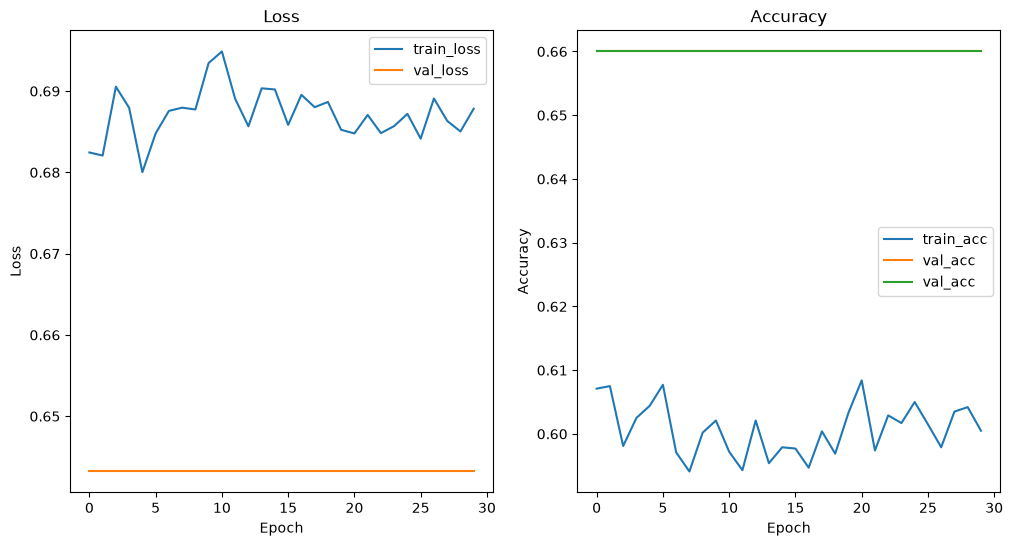

In [26]:

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(history.history["loss"],label="train_loss")
plt.plot(history.history["val_loss"],label="val_loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"],label="train_acc")
plt.plot(history.history["val_accuracy"],label="val_acc")
plt.plot(history.history["val_accuracy"],label="val_acc")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()


              precision    recall  f1-score   support

    WithMask       0.76      0.38      0.51       483
 WithoutMask       0.60      0.89      0.72       509

    accuracy                           0.64       992
   macro avg       0.68      0.63      0.61       992
weighted avg       0.68      0.64      0.61       992



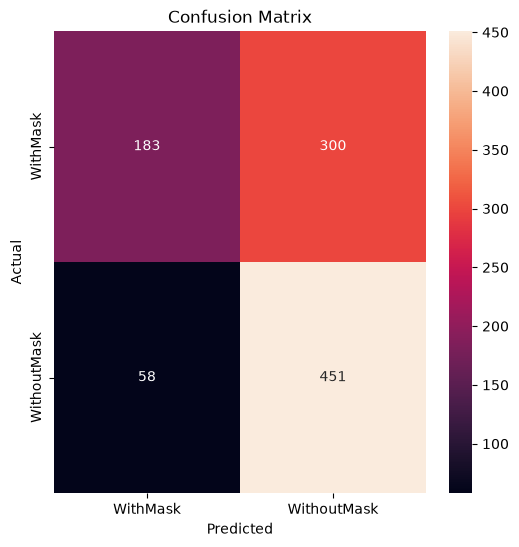

[INFO] saving mask detector model...


d:\proj-python\.dlib\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [27]:
classes=model.predict(test_x,batch_size=batch_size,verbose=0)
pred_index=np.argmax(classes,axis=1)
print(classification_report(test_y.argmax(axis=1),pred_index,target_names=lb.classes_))

cm=confusion_matrix(test_y.argmax(axis=1),pred_index)

plt.figure(figsize=(6,6))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=lb.classes_,yticklabels=lb.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print("[INFO] saving mask detector model...")
model.save("mask_detector.h5")


In [6]:
print("[INFO] loading mask detector model...")
model=tf.keras.models.load_model("mask_detector.h5")
model.save("mask_detector2.keras")
model.summary()


[INFO] loading mask detector model...
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 dense_3 (Dense)             (None, 128)               163968    
                                                                 
 dense_4 (Dense)             (None, 64)                8256      
                                                                 
 dense_5 (Dense)             (None, 2)                 130       
                                                                 
Total params: 24

1. axis=0 → rows     ↓
2. axis=1 → columns  →

In [13]:
import cv2
def predict_img(img_path):
    image=load_img(img_path,target_size=(224,224))
    display_image=img_to_array(image)
    image=preprocess_input(display_image)
    image=np.expand_dims(image,axis=0)
    result=model.predict(image,verbose=0)
    index=np.argmax(result,axis=1)[0]
    confidence=result[0][index]
    class_name=lb.classes_[index]
    print("Prediction:",class_name)
    print("Confidence:",f"{confidence*100:.2f}%")
    plt.imshow(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.tight_layout()
    plt.title(f"Prediction: {class_name} (Confidence: {confidence*100:.2f}%)")
    plt.show()
    return class_name,confidence

Prediction: WithMask
Confidence: 63.78%


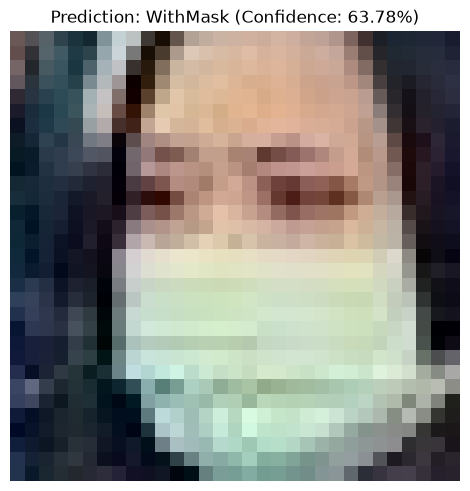

('WithMask', 0.6378015)

In [14]:
predict_img("Test/WithMask/3.png")


Prediction: WithMask
Confidence: 68.38%


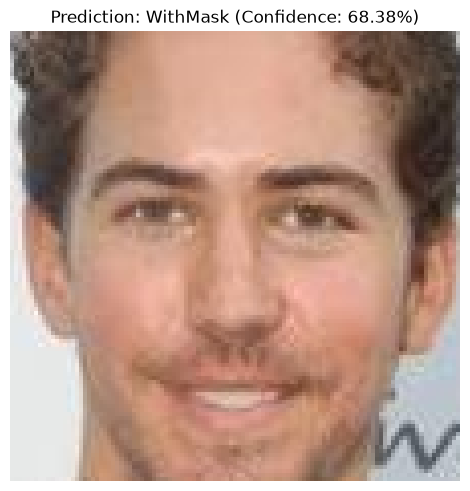

('WithMask', 0.6838148)

In [61]:
predict_img("Test/WithoutMask/85.png")

Prediction: WithMask
Confidence: 72.44%


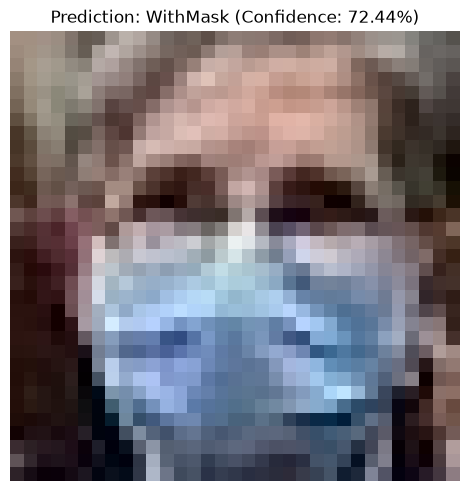

('WithMask', 0.724426)

In [15]:
predict_img("Test/WithMask/147.png")

In [18]:
print(model.input_shape)
print(lb.classes_)

(None, 224, 224, 3)
['WithMask' 'WithoutMask']


In [2]:
model=tf.keras.models.load_model("mask_detector.keras")
model.summary()



Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Func  (None, 7, 7, 1280)        2257984   
 tional)                                                         
                                                                 
 global_average_pooling2d (  (None, 1280)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 128)               163968    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 2)                 258 

In [3]:
import cv2
import numpy as np

def main():

    cap = cv2.VideoCapture(0)



    while True:

        ret, frame = cap.read()

        if not ret:
            print("Video finished.")
            break

        # -------------------------
        # Prepare frame
        # -------------------------

        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        image = cv2.resize(
            image,
            (224, 224)
        )

        # -------------------------
        # Preprocessing
        # -------------------------

        image = preprocess_input(image)

        image = np.expand_dims(
            image,
            axis=0
        )

        # -------------------------
        # Prediction
        # -------------------------

        result = model.predict(
            image,
            verbose=0
        )

        index = np.argmax(
            result,
            axis=1
        )[0]

        confidence = result[0][index]

        class_name = lb.classes_[index]

        # -------------------------
        # Display
        # -------------------------

        text = f"{class_name}: {confidence * 100:.2f}%"


        cv2.putText(
            frame,
            text,
            (20, 50),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (0, 255, 0),
            2
        )

        cv2.imshow(
            "Mask Detection",
            frame
        )

        # Press Q
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

    cap.release()
    cv2.destroyAllWindows()

In [10]:
if __name__ == "__main__":
    main()